In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from typing import Optional, List, Union
import gc
import numpy as np
from scipy.ndimage import gaussian_filter
import deepwave

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
plt.rcParams['font.family'] = ['Times New Roman', 'DejaVu Serif', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['font.size'] = 14
from tqdm import tqdm
import math
import time
import tomli
import random

import os
import shutil
import sys

from example_to_dyy.funcs import draw_kernels

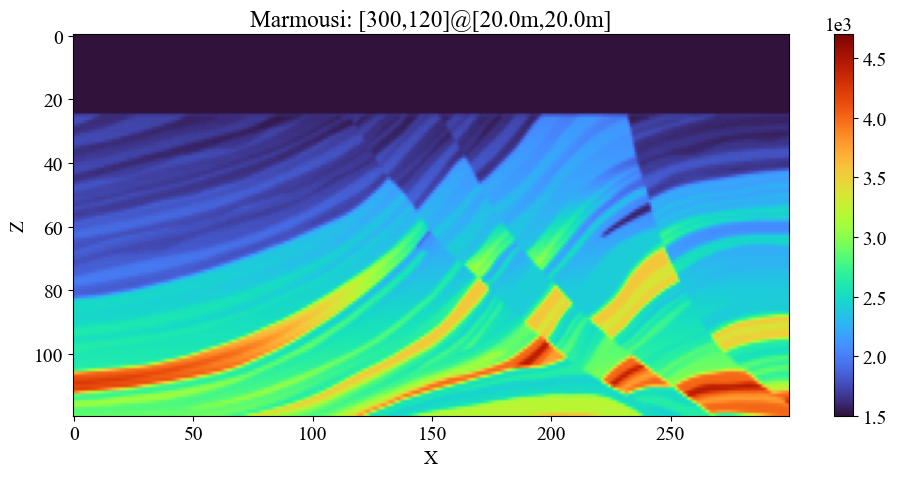

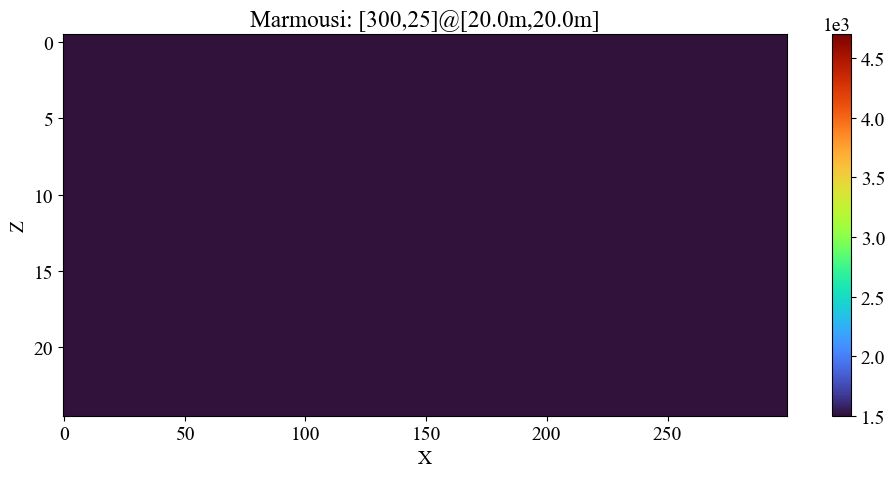

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
cm_v = 'turbo'
cm_r = 'gray'

### 2D model: Marmousi
### unit: m, s, kg/m^3
figsize = (10, 5)

nx, nz = 541, 176
dx, dz = 20.0, 20.0
wl = 25 ## 水层

v_true = torch.from_file('example_to_dyy/models/v_true_zm25.dat', size=nx*nz, dtype=dtype).reshape(nx, nz).to(device)
max_vel, min_vel = v_true.max().item(), 1500.0
norm_v = colors.Normalize(vmax=max_vel, vmin=min_vel)

clip_nx, start_x=300, 125
clip_nz= 120
v_true = v_true[start_x:clip_nx+start_x, 0:clip_nz]
draw_kernels.draw_snap(v_true, figsize=figsize, cmap=cm_v, norm=norm_v, title=f"Marmousi: [{clip_nx},{clip_nz}]@[{dx}m,{dz}m]")

fix_upper_layer = v_true[:, :wl]
draw_kernels.draw_snap(fix_upper_layer, figsize=figsize, cmap=cm_v, norm=norm_v, title=f"Marmousi: [{clip_nx},{wl}]@[{dx}m,{dz}m]")


In [24]:
### 观测系统参数
n_shots, n_sources_per_shot, d_source, first_source, source_depth = 60, 1, 5, 0, 1
is_tow = False ## is_tow==true: 跟随移动观测系统，炮点在检波器中央; is_tow==false: 表面覆盖接收
ng = 300
n_receivers_per_shot, d_receiver, first_receiver, receiver_depth = ng, 1, 0, 0
freq, nt, dt = 10.0, 1500, 0.0036 # ricker主频，时间采样数，采样间隔(不一定满足CFL条件，Deepwave内部插值)
peak_time = 0.3
A0 = 1.0 ## 震源子波振幅
## pml width
pml_width = [20, 20, 20, 20]

# source_locations
source_locations = torch.zeros(n_shots, n_sources_per_shot, 2,  dtype=torch.int32, device=device) ## 形状是(n_shots, n_sources_per_shot, 2), 这相当于是n_shots*n_sources_per_shot个二维坐标
source_locations[..., 1] = source_depth ## z方向的位置
source_locations[:, 0, 0] = (torch.arange(n_shots) * d_source + first_source) ## x方向的位置，由于n_sources_per_shot=1,所以第二个索引只有0
# receiver_locations
receiver_locations = torch.zeros(n_shots, n_receivers_per_shot, 2,  dtype=torch.int32, device=device) ## size: (n_shots, n_receivers_per_shot, 2)
receiver_locations[..., 1] = receiver_depth
if is_tow: ## tow receivers
    for ids in range(n_shots):
        receiver_locations[ids, :, 0] = torch.arange(n_receivers_per_shot) * d_receiver + (ids * d_source + first_source) + first_receiver
else: ## all covered receivers
    receiver_locations[:,:,0] = (torch.arange(n_receivers_per_shot) * d_receiver + first_receiver).repeat(n_shots, 1)
# source_amplitudes
s = A0 * deepwave.wavelets.ricker(freq, nt, dt, peak_time, dtype=dtype)
source_amplitudes = s.repeat(n_shots, n_sources_per_shot, 1).type(torch.float32).to(device) ## size: (n_shots, n_sources_per_shot, nt)

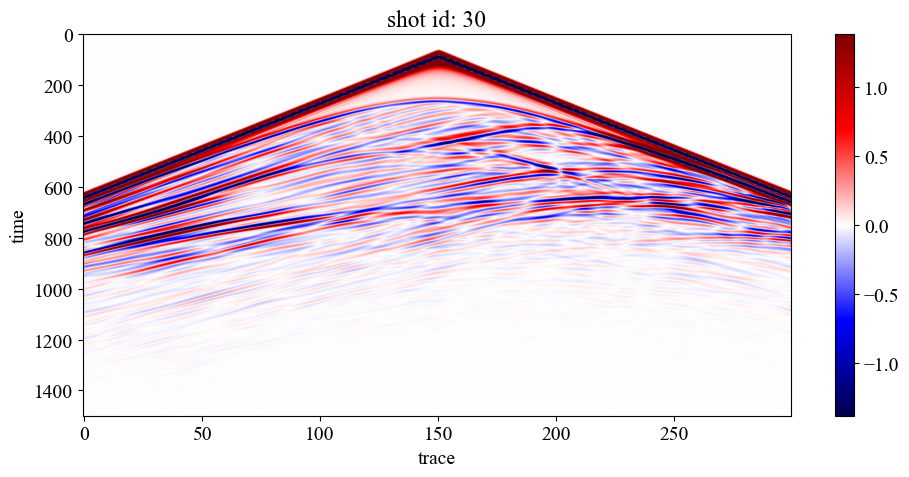

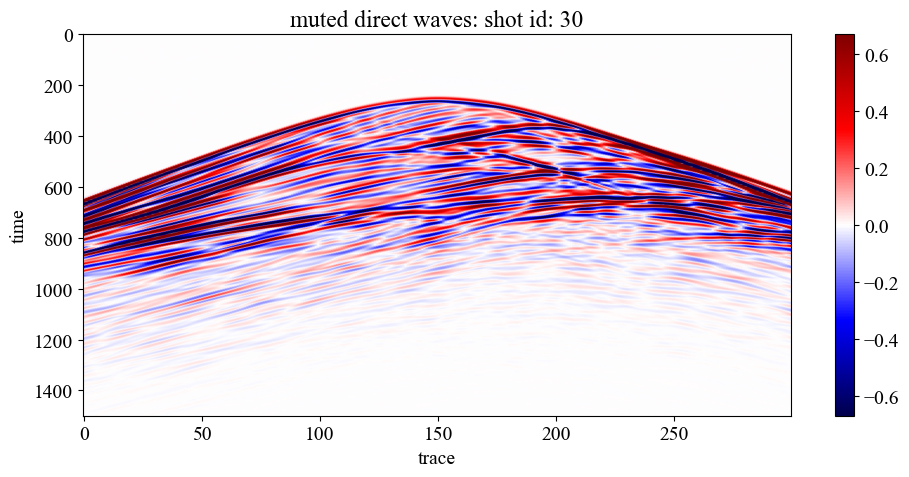

In [25]:
shot0 = deepwave.scalar(
    v_true,
    [dx, dz],
    dt,
    accuracy = 8,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    max_vel=max_vel,
    pml_width=pml_width,
    pml_freq=freq,
)[-1]

#用均匀介质的来去直达波
v_cons = min_vel * torch.ones_like(v_true, dtype=dtype).to(device)
shot_cons = deepwave.scalar(
    v_cons,
    [dx, dz],
    dt,
    accuracy = 8,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    max_vel=max_vel,
    pml_width=pml_width,
    pml_freq=freq,
)[-1]

shot0_masked = shot0 - shot_cons
ids = n_shots // 2
draw_kernels.draw_shot(shot0[ids], title=f'shot id: {ids}')
draw_kernels.draw_shot(shot0_masked[ids], title=f'muted direct waves: shot id: {ids}')

In [26]:
shot0.shape

torch.Size([60, 300, 1500])

In [28]:
from agents.policy_network import SeismicViTControlPolicy
n_shots=shot0.shape[0]
policy = SeismicViTControlPolicy(nx_ctrl=8, nz_ctrl=8, num_bins=100, in_channels=n_shots).to(device)
policy.eval()

x = shot0.unsqueeze(0).to(device)

# 计算每个通道的均值和标准差（维度保持与输入兼容）
mean = x.mean(dim=(2, 3), keepdim=True)   # shape: (1, 91, 1, 1)
std  = x.std(dim=(2, 3), keepdim=True)    # shape: (1, 91, 1, 1)
# 标准化
x_normalized = (x - mean) / (std + 1e-8)
print("ViT input x shape =", tuple(x.shape), "[B,5,nt,nrec]")

with torch.no_grad():
    logits = policy(x_normalized)
print("ViT output logits shape =", tuple(logits.shape), "[B,nx_ctrl,nz_ctrl,n_bins]")

ViT input x shape = (1, 60, 300, 1500) [B,5,nt,nrec]
ViT output logits shape = (1, 8, 8, 100) [B,nx_ctrl,nz_ctrl,n_bins]


In [10]:
logits[0][0]

tensor([[-0.0378,  0.0337,  0.1112,  ...,  0.0738,  0.0081, -0.0256],
        [-0.0378,  0.0337,  0.1112,  ...,  0.0738,  0.0081, -0.0256],
        [-0.0183,  0.0215,  0.1261,  ...,  0.0067, -0.0378,  0.0025],
        ...,
        [-0.0464,  0.0190,  0.1896,  ..., -0.0487, -0.1021, -0.1072],
        [ 0.0085, -0.0185,  0.1629,  ..., -0.0113, -0.1495, -0.1039],
        [ 0.0085, -0.0185,  0.1629,  ..., -0.0113, -0.1495, -0.1039]],
       device='cuda:0')

sampled actions shape = (1, 8, 8) [B,nx_ctrl,nz_ctrl]
v_ctrl shape = (1, 8, 8) [B,nx_ctrl,nz_ctrl]
sampled v_model shape = (1, 300, 120) [B,nx_model,nz_model]


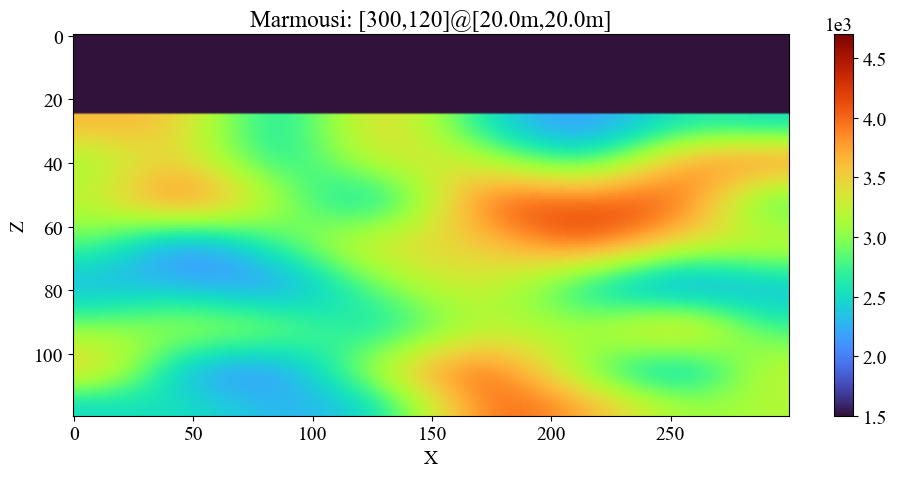

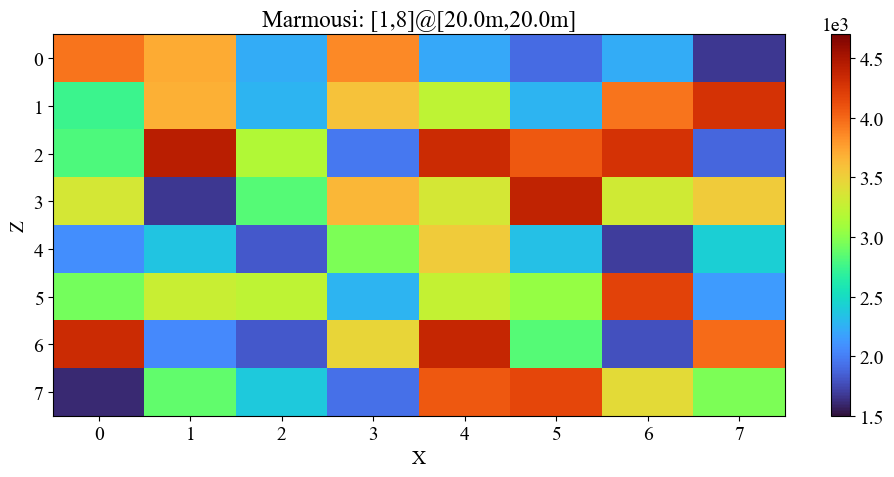

In [38]:
# （3）从 logits 采样一个 sample_model，并可视化
import matplotlib.pyplot as plt
import torch

from agents.grpo_optimizer import bins_to_velocity
from agents.Bspline import bspline2d_prolong

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    actions_n, logp_n = policy.sample(logits, n=1)

actions = actions_n[0]
print("sampled actions shape =", tuple(actions.shape), "[B,nx_ctrl,nz_ctrl]")

v_ctrl = bins_to_velocity(actions, v_min=1500.0, v_max=4500.0, n_bins=100)
print("v_ctrl shape =", tuple(v_ctrl.shape), "[B,nx_ctrl,nz_ctrl]")

nx_model, nz_model = int(v_true.shape[0]), int(v_true.shape[1])
v_model = bspline2d_prolong(v_ctrl, (nx_model, nz_model-wl)) 
fix_upper = fix_upper_layer.unsqueeze(0)  # 形状变为 (1, 300, 25)
v_model = torch.cat([fix_upper,v_model], dim=2)  # 沿最后一维拼接
print("sampled v_model shape =", tuple(v_model.shape), "[B,nx_model,nz_model]")

sample_model = v_model[0].detach().cpu()
v_ctrl_sample = v_ctrl[0].detach().cpu()   # 新增：提取控制点速度场

draw_kernels.draw_snap(v_model, figsize=figsize, cmap=cm_v, norm=norm_v, title=f"Marmousi: [{nx_model},{nz_model}]@[{dx}m,{dz}m]")
draw_kernels.draw_snap(v_ctrl, figsize=figsize, cmap=cm_v, norm=norm_v, title=f"Marmousi: [{v_ctrl.shape[0]},{v_ctrl.shape[1]}]@[{dx}m,{dz}m]")

In [13]:
sample_model.shape

torch.Size([541, 176])

In [14]:
v_true.shape

torch.Size([541, 176])

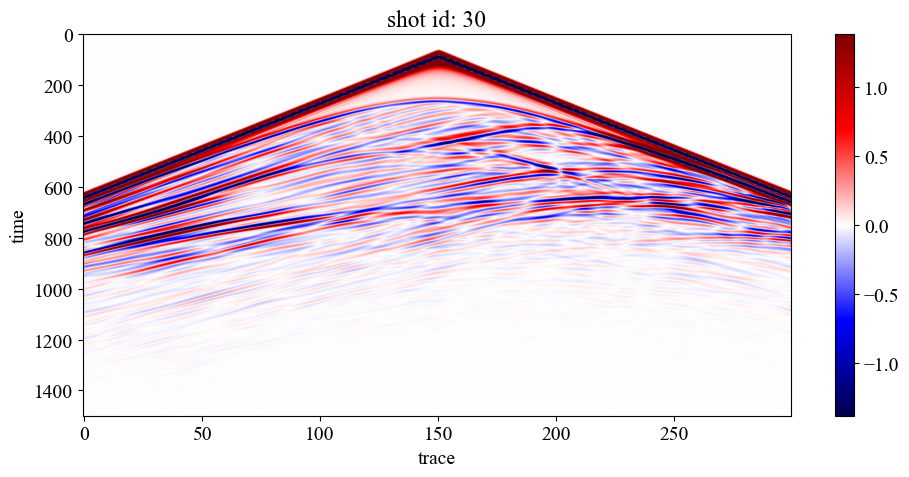

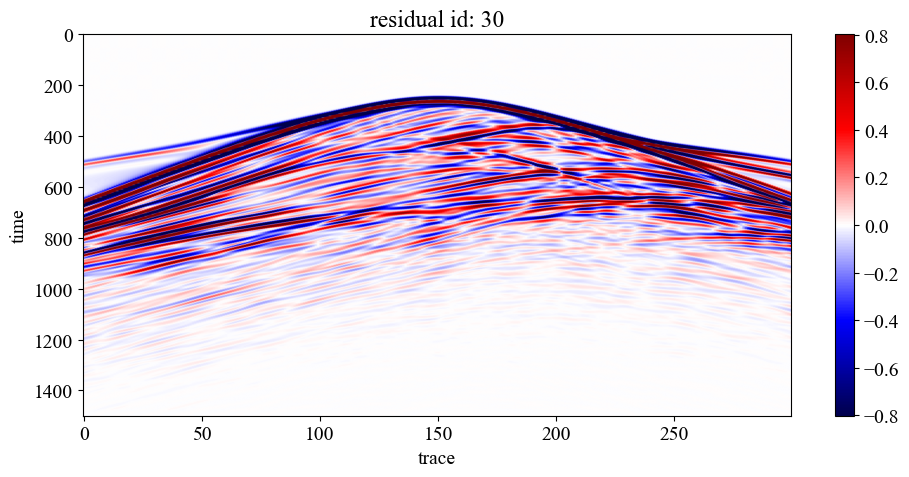

In [39]:
shot_pred = deepwave.scalar(
    sample_model.to(device),
    [dx, dz],
    dt,
    accuracy = 8,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    max_vel=max_vel,
    pml_width=pml_width,
    pml_freq=freq,
)[-1]
draw_kernels.draw_shot(shot0[ids], title=f'shot id: {ids}')

residual = shot0 - shot_pred
draw_kernels.draw_shot(residual[ids], title=f'residual id: {ids}')

In [40]:
# （5）计算 FWI_reward（log 变换 + L1+L2，返回标量）
import torch
from agents.reward_calculator import reward_l1_l2_log

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d_obs_b = shot0.unsqueeze(0).to(device)
d_pred_b = shot_pred.unsqueeze(0).to(device)

r = reward_l1_l2_log(d_pred_b, d_obs_b, k=3.0, c=0.0)
print("FWI_reward shape =", tuple(r.shape), "value =", float(r.item()))

FWI_reward shape = (1,) value = -1941749760.0


In [41]:
from example_to_dyy.funcs import RTM
import importlib
importlib.reload(RTM)
rtm_image = torch.zeros_like(v_true).to(device)
illum_mul = torch.zeros_like(v_true).to(device)

SI=RTM.rtm_imaging_batch_all_forw(rtm_image, sample_model.to(device), [dx, dz], dt, source_amplitudes, source_locations, shot0_masked, receiver_locations,
                batch_size=15, max_vel = max_vel, pml_freq=freq, callback_freq=1,
                illum=True, illum_mul=illum_mul, forw_dt2=False, outSI=True)

100%|██████████| 5/5 [00:04<00:00,  1.12it/s]
RTM's SI= 1.9575e+08
RTM finished! Stacked Image generated. 	[Cost time: 4.6002 seconds]


In [42]:
SI

195746080.0

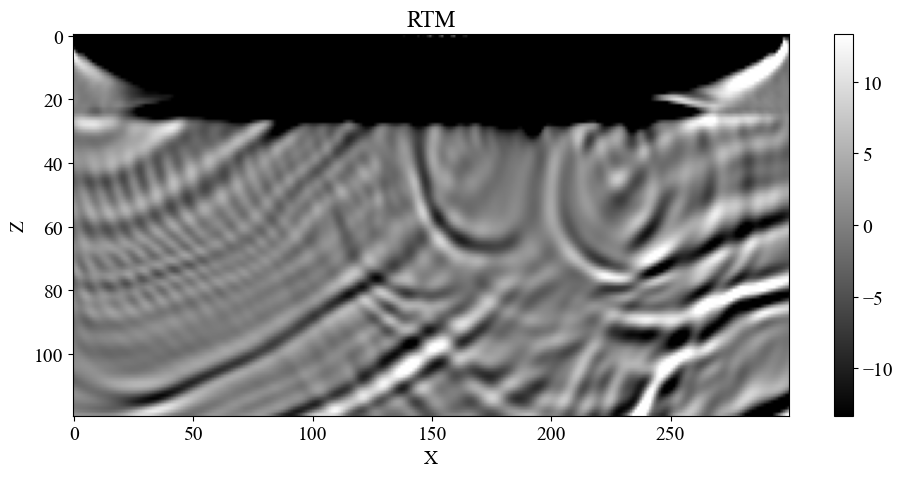

In [43]:
vmax_r = torch.quantile(rtm_image[:,wl:].cpu().abs(), 0.96).item()
norm_r = colors.Normalize(vmax=vmax_r, vmin=-vmax_r)
draw_kernels.draw_snap(rtm_image, cmap=cm_r, norm=norm_r, title='RTM')

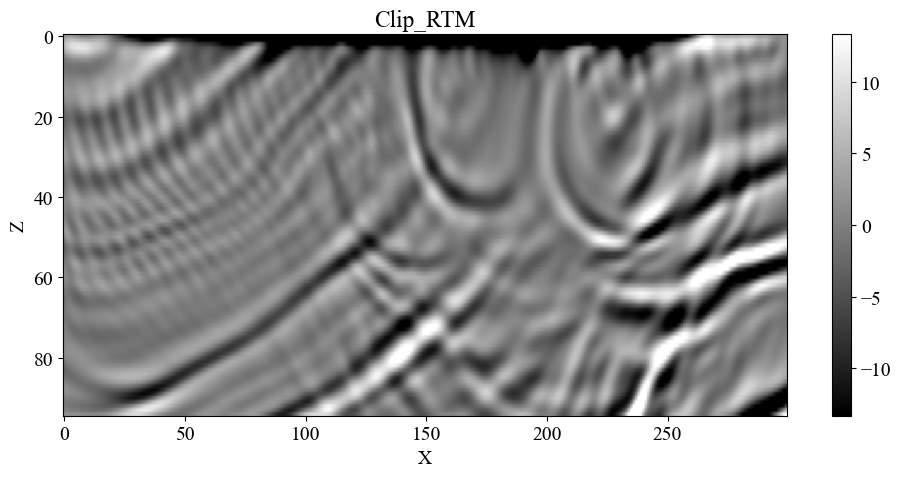

In [44]:
clip_upper_RTM = rtm_image[:,wl:]
draw_kernels.draw_snap(clip_upper_RTM, cmap=cm_r, norm=norm_r, title='Clip_RTM')


In [47]:
si_clip = torch.sum(clip_upper_RTM ** 2).item()   # .item() 将标量张量转为 Python 数值
si_clip

2623677.5